In [5]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from core.data import load_from_kaggle

In [2]:
# moved here to clean dataframes before saving
def clean_data(features):
    features = features.drop(['Patient_ID', 'Diagnosis_Year', 
                              'Diagnosis_Date', 'Survival_Months'], axis=1)
    return features

In [ ]:
# load data
dataset_name = "lung-cancer-clinical-dataset-20152025"
file = "lung_cancer_dataset.csv"
df = pd.read_csv("/".join(["../data/raw/", 
                                              dataset_name, file]))

In [ ]:
# clean and prepare data
X = df.drop('Survived', axis=1)
X = clean_data(X)

y = df.loc[:, 'Survived']

#train-test split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=0,
                                                    stratify=y)

# save as csv files
X_train.to_csv(path_or_buf="../data/processed/X_train.csv")
y_train.to_csv(path_or_buf="../data/processed/y_train.csv")
X_test.to_csv(path_or_buf="../data/processed/X_test.csv")
y_test.to_csv(path_or_buf="../data/processed/y_test.csv")

In [ ]:
df = X_train.copy()

In [ ]:
# dropping columns with no predictive power
df = df.drop(['Patient_ID', 'Diagnosis_Year', 'Diagnosis_Date',
              'Survival_Months'], axis=1)

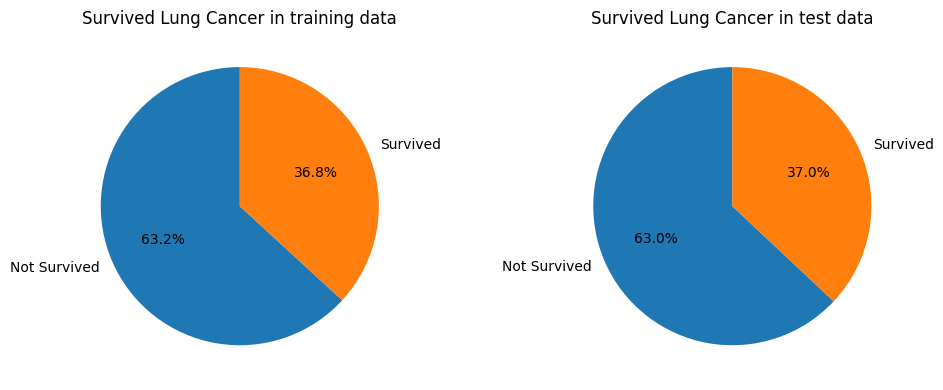

In [4]:
# visualising the distribution in target columns
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# Training data plot
survived = pd.crosstab(index=y_train, columns='count', normalize='columns')
survived.plot(kind='pie',
                y='count',
                labels=['Not Survived', 'Survived'],
                autopct='%1.1f%%',
                legend=False,
                startangle=90,
                title='Survived Lung Cancer in training data',
                ax=axs[0])
axs[0].set_ylabel('')

# Test data plot
survived = pd.crosstab(index=y_test, columns='count', normalize='columns')
survived.plot(kind='pie',
                y='count',
                labels=['Not Survived', 'Survived'],
                autopct='%1.1f%%',
                legend=False,
                startangle=90,
                title='Survived Lung Cancer in test data',
                ax=axs[1])
axs[1].set_ylabel('')

plt.tight_layout()
plt.show()

decided not to resample,because tree-based models like random forest will handle it through "class_weights='balanced'"